In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('bike_sales_india.csv')
df.head()

,State,Avg Daily Distance (km),Brand,Model,Price (INR),Year of Manufacture,Engine Capacity (cc),Fuel Type,Mileage (km/l),Owner Type,Registration Year,Insurance Status,Seller Type,Resale Price (INR),City Tier
0,Karnataka,68.84,Royal Enfield,Hunter 350,252816,2021,672,Electric,78.41,Second,2024,Active,Individual,149934.18,Tier 3
1,Rajasthan,23.80,Bajaj,Dominar 400,131100,2020,769,Hybrid,89.98,Third,2023,Active,Individual,66960.30,Tier 3
2,Madhya Pradesh,27.67,KTM,125 Duke,201016,2020,216,Hybrid,71.46,Second,2023,Active,Dealer,141522.64,Tier 3
3,Karnataka,62.85,Kawasaki,Ninja 300,132482,2021,556,Petrol,51.73,Third,2021,Active,Dealer,56057.22,Tier 1
4,Madhya Pradesh,10.62,Yamaha,FZ V3,231796,2019,298,Petrol,54.72,Third,2019,Not Available,Individual,132538.36,Tier 3


In [4]:
df.shape

(10000, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State                    10000 non-null  str    
 1   Avg Daily Distance (km)  10000 non-null  float64
 2   Brand                    10000 non-null  str    
 3   Model                    10000 non-null  str    
 4   Price (INR)              10000 non-null  int64  
 5   Year of Manufacture      10000 non-null  int64  
 6   Engine Capacity (cc)     10000 non-null  int64  
 7   Fuel Type                10000 non-null  str    
 8   Mileage (km/l)           10000 non-null  float64
 9   Owner Type               10000 non-null  str    
 10  Registration Year        10000 non-null  int64  
 11  Insurance Status         10000 non-null  str    
 12  Seller Type              10000 non-null  str    
 13  Resale Price (INR)       10000 non-null  float64
 14  City Tier                10000 non

In [6]:
df.describe()

,Avg Daily Distance (km),Price (INR),Year of Manufacture,Engine Capacity (cc),Mileage (km/l),Registration Year,Resale Price (INR)
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,42.533128,224328.722400,2019.510500,552.695300,67.188926,2020.96510,133828.973998
std,21.676985,100753.660447,2.907668,261.176292,20.891728,2.74897,66613.220382
min,5.010000,50031.000000,2015.000000,100.000000,25.000000,2015.00000,20532.070000
25%,23.907500,137900.250000,2017.000000,327.000000,50.680000,2019.00000,78680.905000
50%,42.480000,223878.000000,2019.000000,553.000000,69.850000,2022.00000,128148.340000
75%,61.352500,311464.250000,2022.000000,780.000000,84.542500,2023.00000,181048.192500
max,80.000000,399981.000000,2024.000000,1000.000000,100.000000,2024.00000,317302.450000


In [7]:
df.dtypes

State                          str
Avg Daily Distance (km)    float64
Brand                          str
Model                          str
Price (INR)                  int64
Year of Manufacture          int64
Engine Capacity (cc)         int64
Fuel Type                      str
Mileage (km/l)             float64
Owner Type                     str
Registration Year            int64
Insurance Status               str
Seller Type                    str
Resale Price (INR)         float64
City Tier                      str
dtype: object

In [8]:
df_columns = df.columns.str.lower().str.replace(' ', '_')
print(df_columns)

Index(['state', 'avg_daily_distance_(km)', 'brand', 'model', 'price_(inr)',
       'year_of_manufacture', 'engine_capacity_(cc)', 'fuel_type',
       'mileage_(km/l)', 'owner_type', 'registration_year', 'insurance_status',
       'seller_type', 'resale_price_(inr)', 'city_tier'],
      dtype='str')


In [9]:
df.isnull().sum()

State                      0
Avg Daily Distance (km)    0
Brand                      0
Model                      0
Price (INR)                0
Year of Manufacture        0
Engine Capacity (cc)       0
Fuel Type                  0
Mileage (km/l)             0
Owner Type                 0
Registration Year          0
Insurance Status           0
Seller Type                0
Resale Price (INR)         0
City Tier                  0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# Get unique state values
states = df['State'].unique()
print(states)

<StringArray>
[     'Karnataka',      'Rajasthan', 'Madhya Pradesh',    'Maharashtra',
     'Tamil Nadu',         'Punjab',        'Gujarat',  'Uttar Pradesh',
          'Delhi',    'West Bengal']
Length: 10, dtype: str


In [30]:
df['Price (INR)'].sum()

np.int64(2243287224)

In [28]:
df['Price (INR)'].min()

np.int64(50031)

In [29]:
df['Price (INR)'].max()

np.int64(399981)

In [27]:
Depreciation = df['Depreciation'] = (df['Price (INR)'] - df['Resale Price (INR)']).median()
print(Depreciation)

82582.25999999998


In [31]:
df['Year of Manufacture'].value_counts().sort_index()

Year of Manufacture
2015    1060
2016     987
2017     977
2018     961
2019    1019
2020     969
2021     960
2022     987
2023    1029
2024    1051
Name: count, dtype: int64

In [34]:
df.groupby('Year of Manufacture')['Price (INR)'].sum().sort_index(ascending = False)

Year of Manufacture
2024    237897860
2023    231274259
2022    219827345
2021    214642336
2020    210743219
2019    228778293
2018    220531394
2017    220826606
2016    220645598
2015    238120314
Name: Price (INR), dtype: int64

In [36]:
df['Owner Type'].value_counts()

Owner Type
First     3407
Second    3336
Third     3257
Name: count, dtype: int64

In [35]:
df.groupby('Owner Type')['Resale Price (INR)'].mean()

Owner Type
First     134318.877382
Second    133567.409014
Third     133584.417645
Name: Resale Price (INR), dtype: float64

In [37]:
df['Insurance Status'].value_counts()

Insurance Status
Expired          3429
Active           3321
Not Available    3250
Name: count, dtype: int64

In [38]:
df.groupby('Insurance Status')['Resale Price (INR)'].mean()

Insurance Status
Active           133794.968166
Expired          135132.704993
Not Available    132488.186240
Name: Resale Price (INR), dtype: float64

In [39]:
df['Seller Type'].value_counts()

Seller Type
Dealer        5035
Individual    4965
Name: count, dtype: int64

In [40]:
df.groupby('Seller Type')['Price (INR)'].mean()

Seller Type
Dealer        225280.660576
Individual    223363.363142
Name: Price (INR), dtype: float64

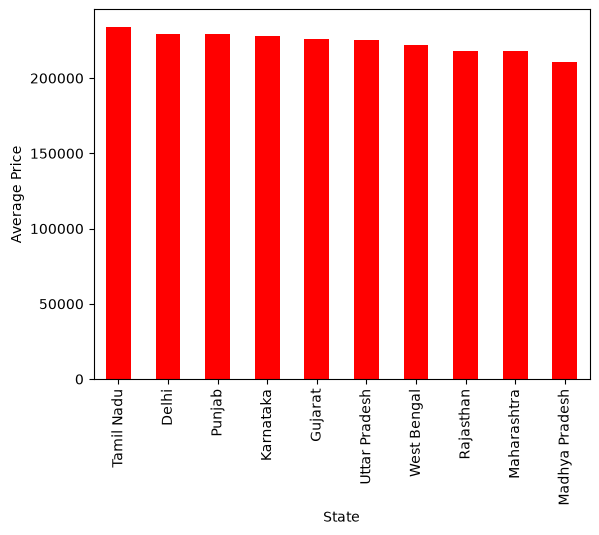

In [13]:
AVG_Price = df.groupby('State')['Price (INR)'].median().sort_values(ascending = False )
AVG_Price.plot(kind = 'bar', color = 'red')
plt.xlabel('State')
plt.ylabel('Average Price')
plt.show()


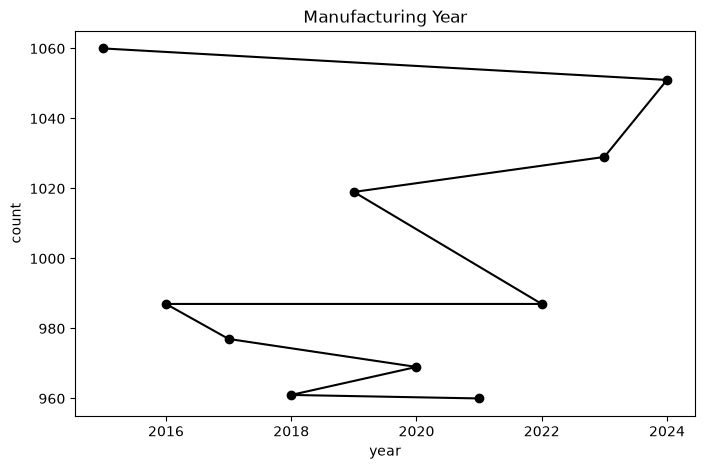

In [14]:
Year = df['Year of Manufacture'].value_counts()
Year.plot(kind = 'line', marker = 'o', color = 'black', figsize= (8,5))

plt.title('Manufacturing Year')
plt.xlabel('year')
plt.ylabel('count')
plt.show()

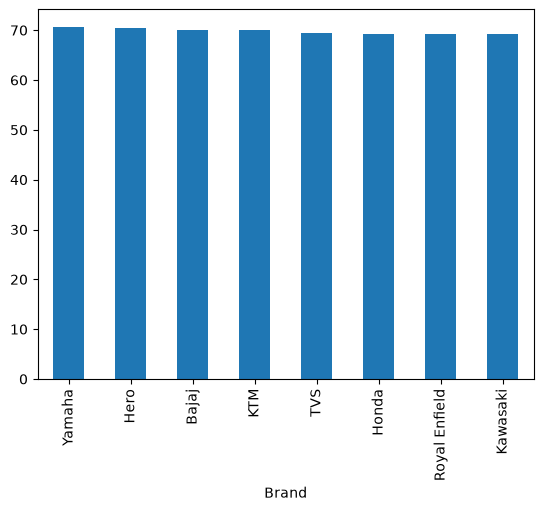

In [15]:
AVG_Mileage = df.groupby('Brand')['Mileage (km/l)'].median().sort_values(ascending = False)
AVG_Mileage.plot(kind = 'bar')
plt.show()

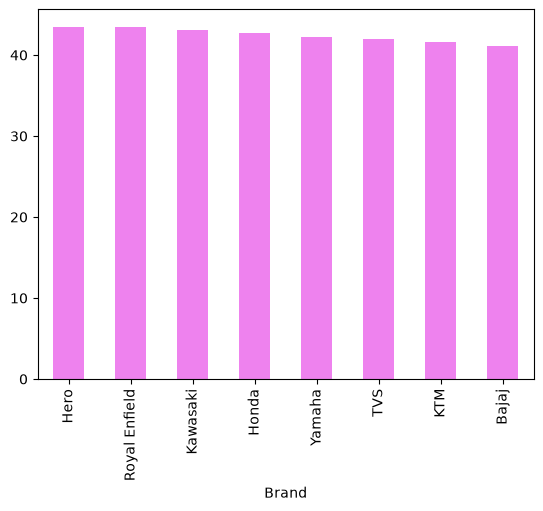

In [16]:
AVG_daily_distance = df.groupby('Brand')['Avg Daily Distance (km)'].median().sort_values(ascending = False)
AVG_daily_distance.plot (kind = 'bar', color = 'violet')
plt.show()

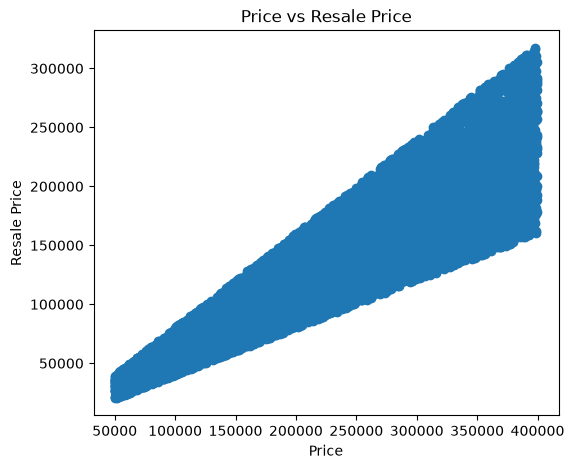

In [17]:
plt.figure(figsize =(6,5))
plt.scatter(df['Price (INR)'], df['Resale Price (INR)'])
plt.title('Price vs Resale Price')
plt.xlabel('Price')
plt.ylabel('Resale Price')
plt.show()


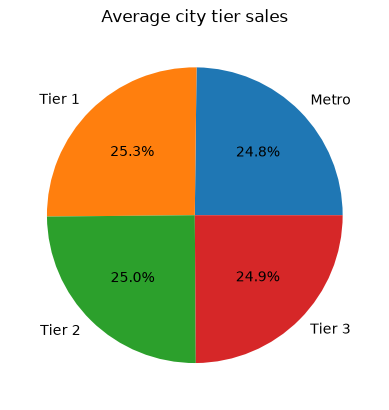

In [18]:
City_tier_sales = df.groupby('City Tier')['Price (INR)'].median()
City_tier_sales.plot(kind = 'pie', autopct = '%1.1f%%')

plt.title('Average city tier sales')

plt.show()


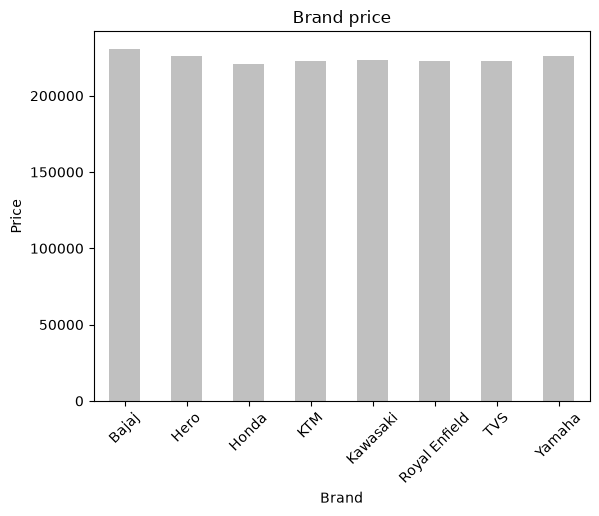

In [19]:
Brand_price = df.groupby('Brand')['Price (INR)'].mean()
Brand_price.plot(kind = 'bar', color = 'silver')

plt.ylabel('Price')
plt.title('Brand price')
plt.xticks(rotation = 45)

plt.show()

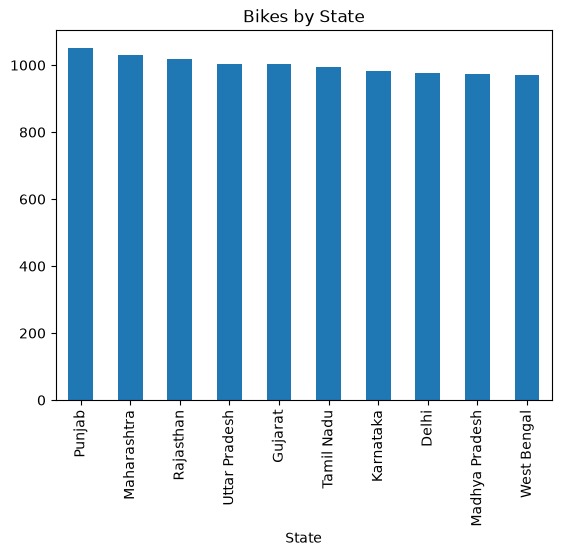

In [20]:
state = df['State'].value_counts()
state.plot(kind = 'bar')
plt.title('Bikes by State')
plt.show()

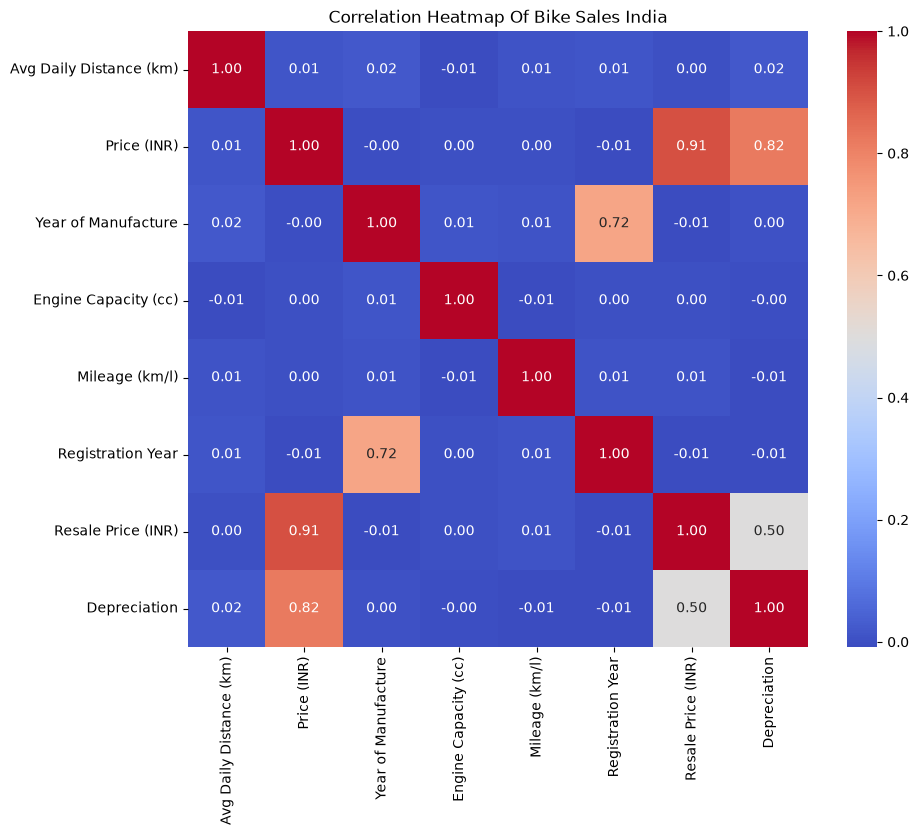

In [21]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt='.2f')
plt.title("Correlation Heatmap Of Bike Sales India")

plt.show()